In [16]:
import os, re, sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr


TIME_WINDOWS = [                    # (name, start_ms, end_ms)
    ('grey_pre',    0,   500),
    ('stimulus',  500,  2500)
]
BIN_MS = 20

# Helper: classify interneuron vs pyramidal
def classify(pop_name: str) -> str:
    s = pop_name.lower()
    if 'pvalb' in s or re.search(r'\bpv', s): return 'PV'
    if 'sst'  in s:                           return 'SST'
    if 'vip' in s or 'htr3a' in s:            return 'VIP'
    return 'Pyr'

def load_spikes(fname: Path | str):
    """Return DataFrame (t_ms, gid)."""
    fname = Path(fname)
    if fname.suffix == '.h5':
        with h5py.File(fname, 'r') as f:
            # assume the single cortical group is /spikes/v1
            ts   = f['spikes']['v1']['timestamps'][...]
            gids = f['spikes']['v1']['node_ids'][...]
    else:  # plain text
        arr = np.loadtxt(fname)
        ts, gids = arr[:,0], arr[:,1].astype(int)
    return pd.DataFrame({'t_ms': ts, 'gid': gids})

def attach_population(df, node_file: Path | str):
    nodes = pd.read_csv(
        node_file, delim_whitespace=True,
        usecols=['id','pop_name','location']
    )
    nodes['type']       = nodes['pop_name'].apply(classify)
    nodes['population'] = nodes['location'] + '_' + nodes['type']
    gid_to_pop = dict(zip(nodes['id'], nodes['population']))
    df['population'] = df['gid'].map(gid_to_pop)
    cells_per_pop = nodes.groupby('population').size()
    return cells_per_pop

In [47]:
fpath_nodes = Path(r'D:\WORK\Salvador\doc\Tuning\Allen_model\v1_nodes.csv')
nodes = pd.read_csv(
    fpath_nodes, delim_whitespace=True,
    usecols=['id', 'pop_name', 'location']
)
nodes['type'] = nodes['pop_name'].apply(classify)
nodes['population'] = nodes['location'] + '_' + nodes['type']
pop_names = nodes['population'].unique()
pop_names

array(['VisL5_Pyr', 'VisL23_Pyr', 'VisL6_PV', 'VisL4_Pyr', 'VisL23_PV',
       'VisL6_VIP', 'VisL23_VIP', 'VisL5_VIP', 'VisL5_PV', 'VisL4_PV',
       'VisL23_SST', 'VisL4_VIP', 'VisL4_SST', 'VisL1_VIP', 'VisL5_SST',
       'VisL6_SST', 'VisL6_Pyr'], dtype=object)

In [18]:
import warnings
warnings.filterwarnings('ignore')

dirpath_root = Path(r'D:\Allen\V1_model\biophysical')
fpath_spikes_lst = list(dirpath_root.iterdir())

bin_edges = np.arange(0, 5000 + BIN_MS, BIN_MS)

X = xr.DataArray(
    data=np.zeros((len(pop_names), len(bin_edges) - 1, len(fpath_spikes_lst))),
    dims=["pop", "time", "trial"],
    coords={
        "pop": pop_names,
        "time": bin_edges[:-1],
        "trial": range(len(fpath_spikes_lst)),
    },
)

for n, fpath_spikes in enumerate(fpath_spikes_lst):
    print(f'Processing trial {n+1}/{len(fpath_spikes_lst)}')

    # Load spikes
    spikes = load_spikes(fpath_spikes)
    run_dur_s = spikes['t_ms'].max() / 1000.0
    n_cells_total = len(np.unique(spikes['gid']))

    # Assign spikes to populations
    cells_per_pop = attach_population(spikes, fpath_nodes)

    # Timecourse
    spikes['bin'] = np.searchsorted(bin_edges, spikes['t_ms'], 'right') - 1
    tc = (spikes.groupby(['population', 'bin']).size()
                    .unstack(fill_value=0) / BIN_MS * 1000)  # Hz
    tc = tc.sort_index()
    tc = tc.div(cells_per_pop, axis=0)

    # Adjust tc to match the length of bin_edges[:-1] by reindexing
    all_bins = np.arange(len(bin_edges) - 1)
    tc = tc.reindex(columns=all_bins, fill_value=0)

    # Store the timecourse
    X.loc[dict(trial=n, pop=tc.index, time=bin_edges[:-1])] = tc.values


Processing trial 1/110
Processing trial 2/110
Processing trial 3/110
Processing trial 4/110
Processing trial 5/110
Processing trial 6/110
Processing trial 7/110
Processing trial 8/110
Processing trial 9/110
Processing trial 10/110
Processing trial 11/110
Processing trial 12/110
Processing trial 13/110
Processing trial 14/110
Processing trial 15/110
Processing trial 16/110
Processing trial 17/110
Processing trial 18/110
Processing trial 19/110
Processing trial 20/110
Processing trial 21/110
Processing trial 22/110
Processing trial 23/110
Processing trial 24/110
Processing trial 25/110
Processing trial 26/110
Processing trial 27/110
Processing trial 28/110
Processing trial 29/110
Processing trial 30/110
Processing trial 31/110
Processing trial 32/110
Processing trial 33/110
Processing trial 34/110
Processing trial 35/110
Processing trial 36/110
Processing trial 37/110
Processing trial 38/110
Processing trial 39/110
Processing trial 40/110
Processing trial 41/110
Processing trial 42/110
P

In [19]:
X.to_netcdf(r'D:\Allen\V1_model\all_trials.nc')

In [20]:
X

<xarray.DataArray (pop: 17, time: 250, trial: 110)>
array([[[1.63895345e-02, 2.08594076e-02, 5.95983074e-03, ...,
         1.19196615e-02, 5.95983074e-03, 8.93974611e-03],
        [2.30943441e-01, 2.50312891e-01, 1.69855176e-01, ...,
         1.99654330e-01, 2.87561833e-01, 1.54955599e-01],
        [3.69509506e-01, 2.80112045e-01, 4.33577686e-01, ...,
         3.06931283e-01, 2.48822933e-01, 3.24810775e-01],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.78389853e-02, 5.35169560e-03, 2.67584780e-03, ...,
         5.35169560e-03, 6.24364486e-03, 2.67584780e-03],
        [3.38940721e-02, 8.91949266e-04, 1.07033912e-02, ...,
         8.91949266e-03, 8.02754339e-03, 3.56779706e-03],
...
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 2.62228593e-03, 0.00000000e+00, ...,
         1.74819062e-03, 2.62228593e-03, 0.00000000e+00],
        [1.97545540e-01, 3.14674312e-02, 1.57337156e-02, ...,
         6.55571484e-02, 6.11866718e-02, 2.18523828e-02],
        [2.21146114e-01, 4.80752421e-02, 1.35484773e-01, ...,
         1.85308206e-01, 8.91577218e-02, 3.23415265e-02],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]])
Coordinates:
  * pop      (pop) object 'VisL5_Pyr' 'VisL23_Pyr' ... 'VisL6_SST' 'VisL6_Pyr'
  * time     (time) int32 0 20 40 60 80 100 ... 4880 4900 4920 4940 4960 4980
  * trial    (trial) int32 0 1 2 3 4 5 6 7 8 ... 102 103 104 105 106 107 108 109

In [48]:
X_ = X.sel(time=slice(100, 500)).stack(
    merged_dim=("trial", "time"))

layers = ['23', '4', '5', '6']
cell_types = ['Pyr', 'PV', 'SST', 'VIP']

for l in layers:
    for c in cell_types:
        pop = f'VisL{l}_{c}'
        x_avg = np.mean(X_.sel(pop=pop).values)
        x_med = np.median(X_.sel(pop=pop).values)
        x_std = np.std(X_.sel(pop=pop).values)
        print(f'{pop}: {x_avg:.02f} +- {x_std:.02f} Hz (median: {x_med:.02f} Hz)')
    print()

VisL23_Pyr: 0.04 +- 0.02 Hz (median: 0.03 Hz)
VisL23_PV: 0.24 +- 0.13 Hz (median: 0.22 Hz)
VisL23_SST: 0.16 +- 0.38 Hz (median: 0.00 Hz)
VisL23_VIP: 0.33 +- 0.49 Hz (median: 0.17 Hz)

VisL4_Pyr: 0.07 +- 0.04 Hz (median: 0.06 Hz)
VisL4_PV: 2.60 +- 0.53 Hz (median: 2.54 Hz)
VisL4_SST: 0.26 +- 0.61 Hz (median: 0.00 Hz)
VisL4_VIP: 0.21 +- 0.38 Hz (median: 0.04 Hz)

VisL5_Pyr: 0.47 +- 0.15 Hz (median: 0.45 Hz)
VisL5_PV: 2.00 +- 0.44 Hz (median: 1.96 Hz)
VisL5_SST: 0.01 +- 0.03 Hz (median: 0.00 Hz)
VisL5_VIP: 0.01 +- 0.03 Hz (median: 0.00 Hz)

VisL6_Pyr: 0.21 +- 0.10 Hz (median: 0.19 Hz)
VisL6_PV: 1.10 +- 0.34 Hz (median: 1.05 Hz)
VisL6_SST: 0.03 +- 0.08 Hz (median: 0.00 Hz)
VisL6_VIP: 0.20 +- 0.24 Hz (median: 0.12 Hz)



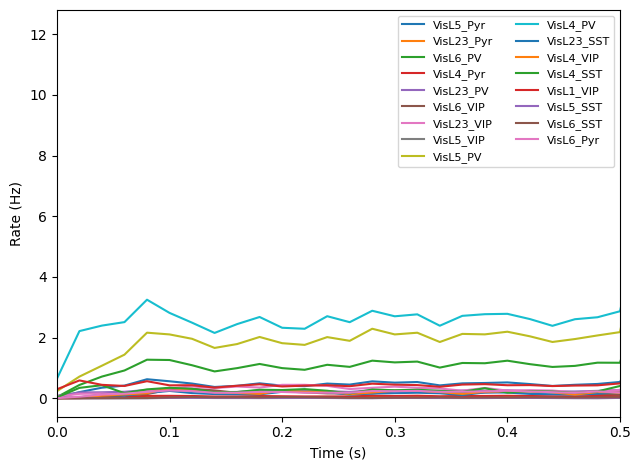

In [40]:
tt = bin_edges[:-1] / 1000.0

#X_avg = X.isel(trial=slice(80, 90)).mean(dim='trial')
X_avg = X.mean(dim='trial')

#plt.figure(figsize=(10,6))
plt.figure()
for pop in X.pop.values:
    plt.plot(tt, X_avg.sel(pop=pop), label=pop)
plt.legend(fontsize=8, ncol=2)
plt.xlabel('Time (s)')
plt.ylabel(f'Rate (Hz)')
plt.tight_layout()
#plt.xlim(0, 3)
plt.xlim(0, 0.5)
plt.show()

(0.0, 3.0)

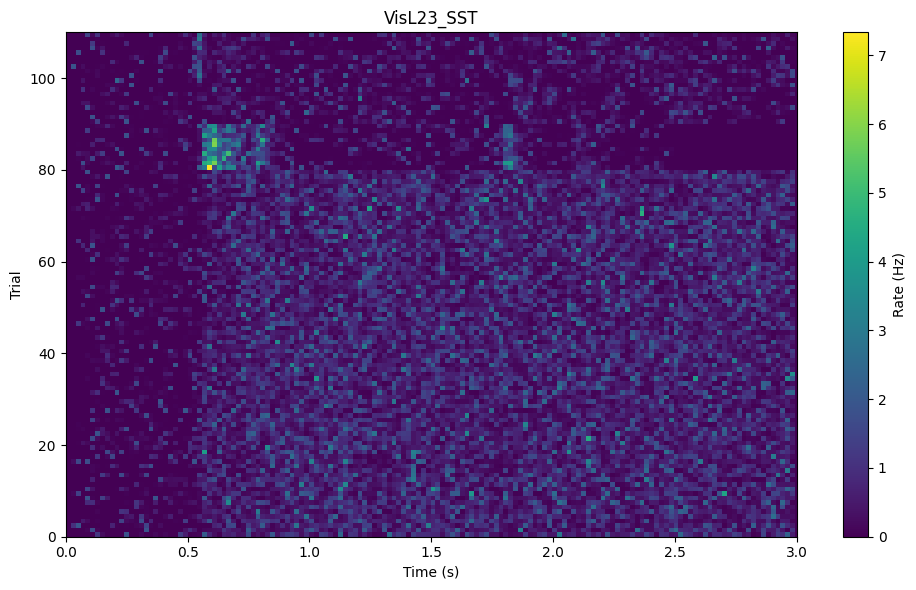

In [42]:
pop = 'VisL23_SST'

plt.figure(figsize=(10, 6))
X_ = X.sel(pop=pop).T
plt.imshow(X_, aspect='auto', origin='lower',
           extent=[tt[0], tt[-1], 0, len(fpath_spikes_lst)])
plt.colorbar(label='Rate (Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Trial')
plt.title(f'{pop}')
plt.tight_layout()
plt.xlim(0, 3)

In [37]:
fpath_spikes_lst[89].stem

'spikes_flash_trial9'